In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# A Lightweight Multi-Modal Driver Distraction Detection System

## Milestone 1: Data Engineering & Exploratory Data Analysis (EDA)
This notebook establishes the research-grade data pipeline for the State Farm Distracted Driver Detection dataset. We focus on automated extraction, subject-aware data splitting, and robust PyTorch data loading mechanisms.

### 1. Imports
We import essential libraries for file handling, data manipulation, computer vision, and deep learning.

In [2]:
import os
import zipfile
import json
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Tuple, List, Dict, Any
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import GroupShuffleSplit

# Configuration
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATASET_ZIP = '/content/drive/MyDrive/Research-Paper/Dataset/state-farm-distracted-driver-detection.zip'
EXTRACT_PATH = Path('/content/dataset')
OUTPUT_DIR = Path('/content/outputs/dataset_analysis')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

### 2. Dataset Extraction
Automatically extract the dataset if it hasn't been extracted yet to ensure reproducibility and save time.

In [3]:
def extract_dataset(zip_path: str, target_path: Path) -> None:
    """Extracts the dataset zip file to a target directory."""
    if not target_path.exists():
        print(f"Extracting {zip_path} to {target_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(target_path)
        print("Extraction complete.")
    else:
        print("Dataset already extracted.")

extract_dataset(DATASET_ZIP, EXTRACT_PATH)

Extracting /content/drive/MyDrive/Research-Paper/Dataset/Copy of state-farm-distracted-driver-detection.zip to /content/dataset...
Extraction complete.


### 3. Subject-Wise Split
To avoid data leakage, we ensure that images of the same driver do not appear in both the training and validation sets.

In [9]:
def prepare_subject_split(csv_path: str, val_size: float = 0.2) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Performs a subject-wise split to ensure no driver leakage."""
    df = pd.read_csv(csv_path)

    # GroupShuffleSplit ensures 'subject' (driver) is the grouping factor
    # Fixed: Changed random_seed to random_state
    gss = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=SEED)
    train_idx, val_idx = next(gss.split(df, groups=df['subject']))

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

    return train_df, val_df

csv_file = EXTRACT_PATH / 'driver_imgs_list.csv'
train_df, val_df = prepare_subject_split(str(csv_file))

### 4. PyTorch Dataset Class
Implementing a custom Dataset class to handle image loading and transformations.

In [5]:
class DriverDataset(Dataset):
    """Custom Dataset for State Farm Distracted Driver images."""
    def __init__(self, df: pd.DataFrame, root_dir: Path, transform: Any = None):
        self.df = df
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(df['classname'].unique())
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        row = self.df.iloc[idx]
        img_path = self.root_dir / 'imgs' / 'train' / row['classname'] / row['img']
        image = Image.open(img_path).convert('RGB')
        label = self.class_to_idx[row['classname']]

        if self.transform:
            image = self.transform(image)

        return image, label

### 5. DataLoaders and Preprocessing
Defining augmentations for training and standard normalization for validation.

In [10]:
# ImageNet constants
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
SIZE = (224, 224)

train_transforms = transforms.Compose([
    transforms.Resize(SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

val_transforms = transforms.Compose([
    transforms.Resize(SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# These will now work since train_df and val_df are defined
train_dataset = DriverDataset(train_df, EXTRACT_PATH, transform=train_transforms)
val_dataset = DriverDataset(val_df, EXTRACT_PATH, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

### 6. Visualization & Statistics
Analyzing class balance and driver distribution.

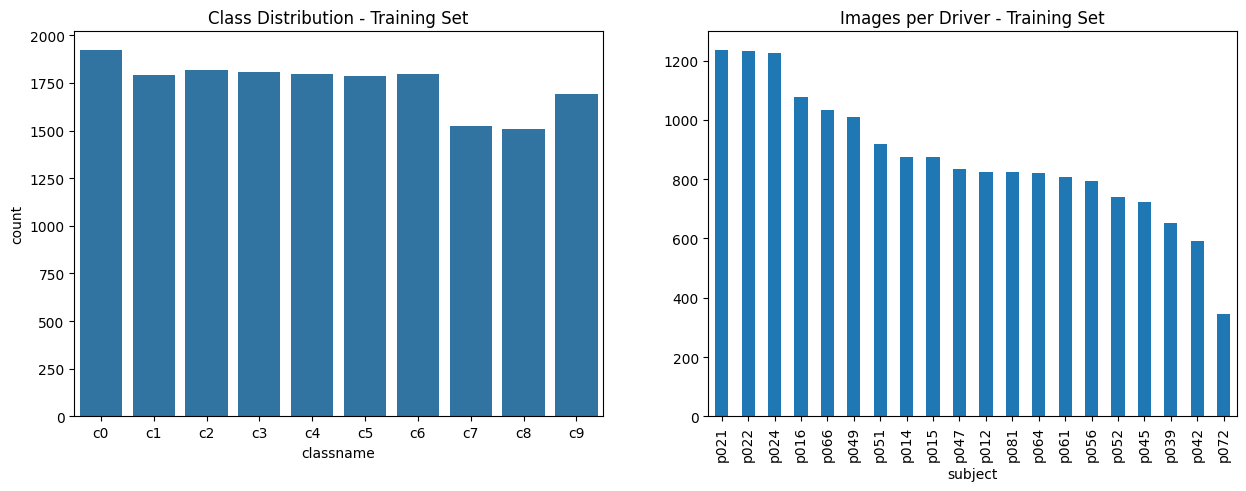

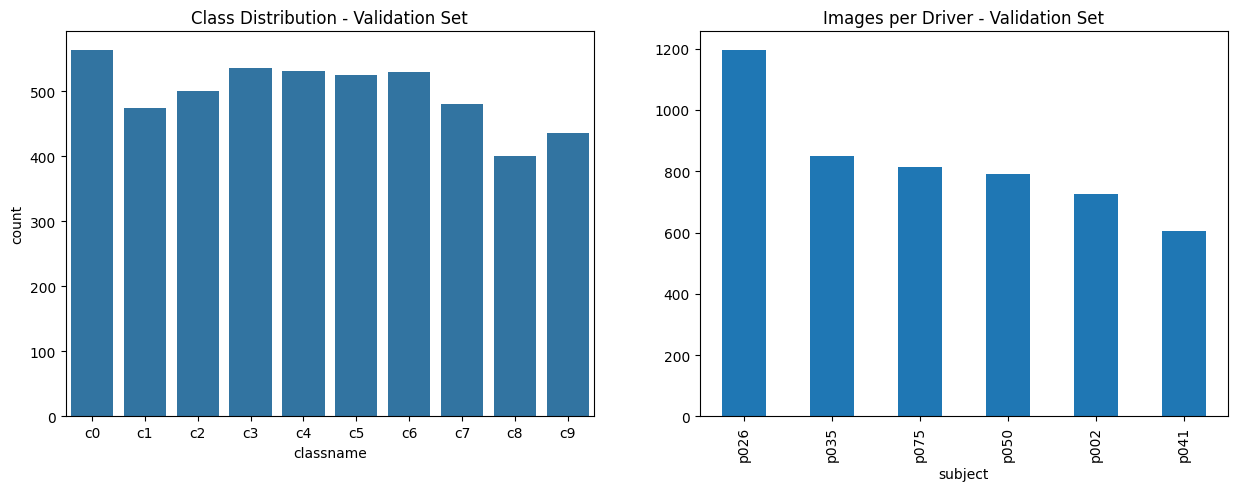


Dataset Statistics:
total_images: 22424
training_size: 17446
validation_size: 4978
num_drivers_train: 20
num_drivers_val: 6
classes: ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']


In [11]:
def plot_stats(df: pd.DataFrame, title_suffix: str):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    sns.countplot(data=df, x='classname', order=sorted(df['classname'].unique()))
    plt.title(f'Class Distribution - {title_suffix}')

    plt.subplot(1, 2, 2)
    df['subject'].value_counts().plot(kind='bar')
    plt.title(f'Images per Driver - {title_suffix}')
    plt.show()

plot_stats(train_df, "Training Set")
plot_stats(val_df, "Validation Set")

# Statistics Dictionary
stats = {
    "total_images": len(train_df) + len(val_df),
    "training_size": len(train_df),
    "validation_size": len(val_df),
    "num_drivers_train": int(train_df['subject'].nunique()),
    "num_drivers_val": int(val_df['subject'].nunique()),
    "classes": list(train_dataset.class_to_idx.keys())
}

with open(OUTPUT_DIR / 'dataset_statistics.json', 'w') as f:
    json.dump(stats, f, indent=4)

with open(OUTPUT_DIR / 'subject_split.json', 'w') as f:
    json.dump({"train_subjects": list(train_df['subject'].unique()),
               "val_subjects": list(val_df['subject'].unique())}, f, indent=4)

print("\nDataset Statistics:")
for k, v in stats.items(): print(f"{k}: {v}")

### 7. Completion
Verify the pipeline is ready for modeling.

In [8]:
print("Milestone 1 Completed Successfully")

Milestone 1 Completed Successfully
